Взглянем на все фичи, что у нас есть, попробуем придумать новые, избавимся от ненужных, преобразуем категориальные и ординальные в числовые.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
train_df = pd.read_csv('./content/train.csv')

In [3]:
train_df.columns.to_frame()

,0
PassengerId,PassengerId
Survived,Survived
Pclass,Pclass
Name,Name
Sex,Sex
Age,Age
SibSp,SibSp
Parch,Parch
Ticket,Ticket
Fare,Fare


# Работа с null-значениями

Посмотрим сначала какие фичи имеют null-значения:

In [4]:
train_df.isnull().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
dtype: bool

Видим, null-значения присутствуют в *Age*, *Cabin* и *Embarked*. Фича *Cabin* не учавствует в обучении модели, поэтому не обращаем на неё внимаем, а вот *Age* и *Embarked* рассмотрим подробнее:

In [5]:
print(f'Count null-value Age is {train_df['Age'].isnull().sum()} \nCount null-value Embarked is {train_df['Embarked'].isnull().sum()} \n\nAll samples is {train_df.shape[0]}')

Count null-value Age is 177 
Count null-value Embarked is 2 

All samples is 891


## Embarked null

В столбце *Embarked* всего-лишь 2 null-значений. Их можно заполнить самым частым значением:

In [6]:
train_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [7]:
train_df.loc[train_df['Embarked'].isnull(), 'Embarked'] = 'S'

In [8]:
train_df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

## Age null

В *Age* null-значений уже 177 из 891. Можно было бы заполнить их средним значением общего количества людей или средним значением в зависимости от пола.\
Но если посмотреть в данные, у каждого из людей в имени есть их "почётные титулы":

In [9]:
train_df['Name'].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: str

Среди них встречаются такие титулы как *Mr.*, *Mrs*, *Miss.*, *Master.* и ещё несколько. *Mr* могут называть взрослого мужчину, а *Master* мальчика.\
Выделим у каждого из них своё почётный титул и посмотрим на среднее значение возраста каждого титула:

In [10]:
train_df['Honorifics'] = train_df['Name'].str.extract('([A-Z][a-z]+)\.', expand=True)
train_df[['Name', 'Honorifics']]

,Name,Honorifics
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
...,...,...
886,"Montvila, Rev. Juozas",Rev
887,"Graham, Miss. Margaret Edith",Miss
888,"Johnston, Miss. Catherine Helen ""Carrie""",Miss
889,"Behr, Mr. Karl Howell",Mr


In [11]:
pd.crosstab(index=train_df['Sex'], columns=train_df['Honorifics']).style.background_gradient(cmap='coolwarm')

Honorifics,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


Видно, что есть редкие титулы: *Capt*, *Col*, *Countess*, *Don*, *Dr*, *Jonkheer*, *Lady*, *Major*, *Rev* и *Sir*.\
А если синонимы: *Mlle* и *Ms* означает то же самое, что и *Miss*, а *Mme* означает *Mrs*.

Синонимы лучше объеденить в самый популярный титул, а редкие титулы в *Rare*:

In [12]:
train_df['Honorifics'] = train_df['Honorifics'].replace(['Capt', 'Col', 'Countess', 'Don', 'Dr', 'Jonkheer', 'Lady', 'Major', 'Rev', 'Sir'], 'Rare')
train_df['Honorifics'] = train_df['Honorifics'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Honorifics'] = train_df['Honorifics'].replace('Mme', 'Mrs')

pd.crosstab(index=train_df['Sex'], columns=train_df['Honorifics']).style.background_gradient(cmap='coolwarm')

Honorifics,Master,Miss,Mr,Mrs,Rare
Sex,,,,,
female,0,185,0,126,3
male,40,0,517,0,20


In [13]:
train_df.groupby('Honorifics')['Age'].mean()

Honorifics
Master     4.574167
Miss      21.845638
Mr        32.368090
Mrs       35.788991
Rare      45.545455
Name: Age, dtype: float64

Теперь знаем средний возраст каждого титула. Присвоим его null-значениям:

In [14]:
train_df.loc[(train_df['Age'].isnull()) & (train_df['Honorifics']=='Master'), 'Age'] = 5
train_df.loc[(train_df['Age'].isnull()) & (train_df['Honorifics']=='Miss'), 'Age'] = 22
train_df.loc[(train_df['Age'].isnull()) & (train_df['Honorifics']=='Mr'), 'Age'] = 32
train_df.loc[(train_df['Age'].isnull()) & (train_df['Honorifics']=='Mrs'), 'Age'] = 36
train_df.loc[(train_df['Age'].isnull()) & (train_df['Honorifics']=='Rare'), 'Age'] = 46

train_df.isnull().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age            False
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked       False
Honorifics     False
dtype: bool

# Непрерывные величины в дискретные
Среди непрерывных величин у нас есть *Age* и *Fare*, обе необходимы для обучения модели. Преобразуем обе в дискрестные:

## Age_Group
Всего на корабле возраста от 0 до 80 лет. Разделим их на 8 частей (каждая по 10 лет):

In [15]:
train_df['Age_Group'] = pd.cut(x=train_df['Age'],
                               bins=[0, 10, 20, 30, 40, 50, 60, 70, 80],
                               labels=[0, 1, 2, 3, 4, 5, 6, 7],
                               include_lowest=True)
train_df['Age_Group'].value_counts()

Age_Group
3    291
2    266
1    115
4     87
0     68
5     42
6     17
7      5
Name: count, dtype: int64

## Fare_Range
Цены на билеты были очень разные, варьировались в диапазоне от 0 до 500 долларов, при чём билеты за 0\\$ могли попасться и в классе 1.\
Проще всего будет разделить билеты на 3 диапазона с равным количеством людей в каждом:

In [16]:
train_df['Fare_Range'] = pd.qcut(x=train_df['Fare'],
                                 q=5,
                                 labels=[0, 1, 2, 3, 4])
train_df['Fare_Range'].value_counts()

Fare_Range
1    184
3    180
0    179
4    176
2    172
Name: count, dtype: int64

# Создание новых фичей
*Sibsp* показывает количество братье, сестёр и супругов на корабле, а *Parch* — количество родителей и детей.\
Обе этих фичи можно объединить в одну — *Family_Size*:

In [25]:
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch']
train_df[['SibSp', 'Parch', 'Family_Size']]

,SibSp,Parch,Family_Size
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0
...,...,...,...
886,0,0,0
887,0,0,0
888,1,2,3
889,0,0,0


Если у человека *Family_Size* = 0, значит он плыл один. Тогда для таких людей можно сделать фичу *Alone*:

In [29]:
train_df['Alone'] = 0
train_df.loc[train_df['Family_Size'] == 0, 'Alone'] = 1
train_df[['Family_Size', 'Alone']]

,Family_Size,Alone
0,1,0
1,1,0
2,0,1
3,1,0
4,0,1
...,...,...
886,0,1
887,0,1
888,3,0
889,0,1


# Преобразование строковых фичей в числовые
Модель не может обучаться на строковых данных, поэтому фичи *Sex*, *Embarked* и *Honorifics* необходимо преобразовать в числовые данные:

In [41]:
train_df['Sex'] = train_df['Sex'].replace(['male', 'female'], [0, 1])
train_df['Embarked'] = train_df['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2])
train_df['Honorifics'] = train_df['Honorifics'].replace(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], [0, 1, 2, 3, 4])
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Honorifics,Age_Group,Fare_Range,Family_Size,Alone
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,0,2,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,1,3,4,1,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,2,2,1,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,1,3,4,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,0,3,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,0,4,2,2,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,0,2,1,3,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,22.0,1,2,W./C. 6607,23.4500,NaN,0,2,2,3,3,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,1,0,2,3,0,1


# Откажемся от ненужных фичей
В обучении не будут учавствовать следующие признаки:
- *PassengerId* — уникальный идентификатор не предоставляет никакой информации о вероятности выживания пассажира;
- *Name* — имя не предоставляет никакой информации о выживании пассажира;
- *Age* — заменена категориальной фичой *Age_Group*;
- *Ticket* — номер билета не предоставляет никакой информации о выживании пассажира;
- *Fare* — заменена категориальный фичой *Fare_Range*;
- *Cabin* — номер каюты не предоставляет никакой информации о выживании пассажира.

In [44]:
train_df = train_df.drop(columns=['PassengerId', 'Name', 'Age', 'Ticket', 'Fare', 'Cabin'])
train_df

,Survived,Pclass,Sex,SibSp,Parch,Embarked,Honorifics,Age_Group,Fare_Range,Family_Size,Alone
0,0,3,0,1,0,0,0,2,0,1,0
1,1,1,1,1,0,1,1,3,4,1,0
2,1,3,1,0,0,0,2,2,1,0,1
3,1,1,1,1,0,0,1,3,4,1,0
4,0,3,0,0,0,0,0,3,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,0,0,0,4,2,2,0,1
887,1,1,1,0,0,0,2,1,3,0,1
888,0,3,1,1,2,0,2,2,3,3,0
889,1,1,0,0,0,1,0,2,3,0,1


# Корреляции новых признаков

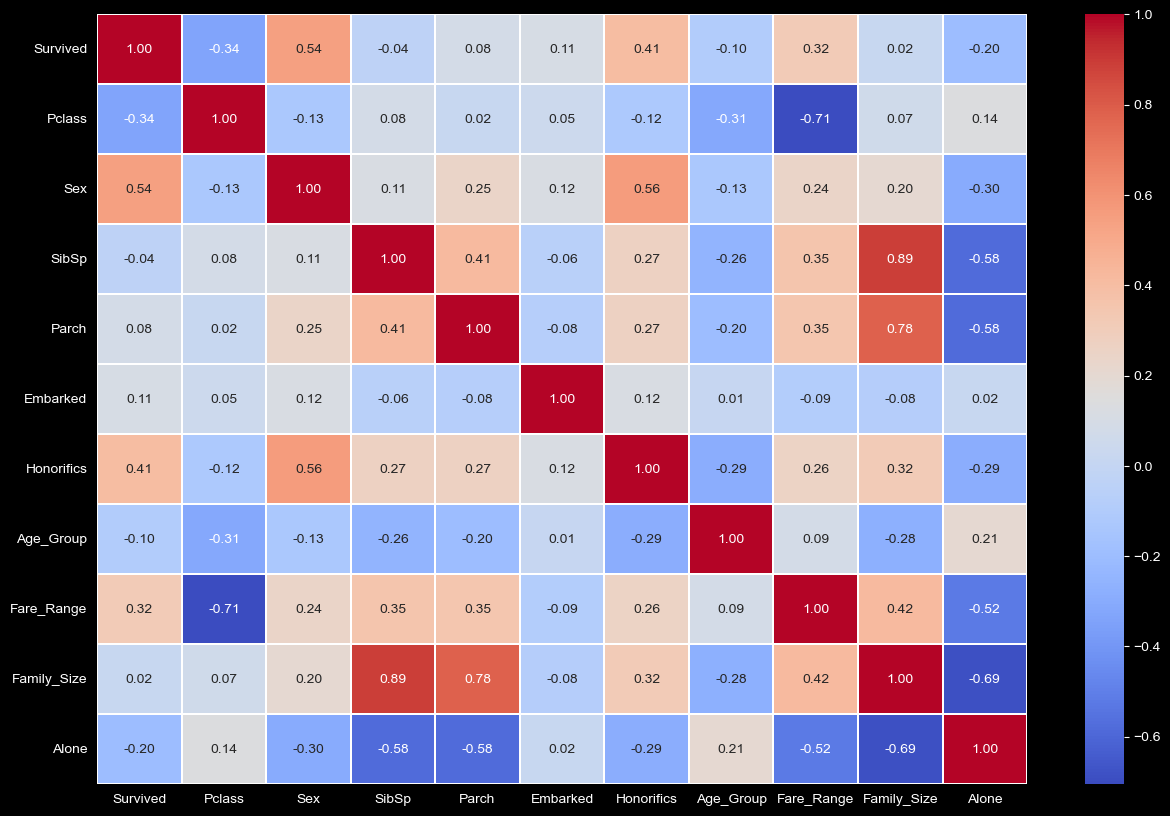

In [47]:
plt.figure(figsize=(15, 10))
sns.heatmap(data=train_df.corr(),
            annot=True,
            cmap='coolwarm',
            linewidth = 0.2,
            fmt='.2f')
plt.show()

Видно, что для некоторых фичей корреляция достаточно большая: 0.89, 0.78, -0.71.\
Но т.к. наша цель — выбить максимально точный предикт модели, то оставим данные фичи и будем обучать модель с помощью них.